In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('../data/AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [25]:
df.columns=df.columns.str.replace(' ', '_').str.lower()

In [26]:
len(df.columns)

80

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ms_subclass      2930 non-null   int64  
 1   ms_zoning        2930 non-null   object 
 2   lot_frontage     2440 non-null   float64
 3   lot_area         2930 non-null   int64  
 4   street           2930 non-null   object 
 5   alley            198 non-null    object 
 6   lot_shape        2930 non-null   object 
 7   land_contour     2930 non-null   object 
 8   utilities        2930 non-null   object 
 9   lot_config       2930 non-null   object 
 10  land_slope       2930 non-null   object 
 11  neighborhood     2930 non-null   object 
 12  condition_1      2930 non-null   object 
 13  condition_2      2930 non-null   object 
 14  bldg_type        2930 non-null   object 
 15  house_style      2930 non-null   object 
 16  overall_qual     2930 non-null   int64  
 17  overall_cond  

In [28]:
null_values=df.isnull().sum()
null_values[null_values>0].sort_values(ascending=False)

pool_qc           2917
misc_feature      2824
alley             2732
fence             2358
mas_vnr_type      1775
fireplace_qu      1422
lot_frontage       490
garage_qual        159
garage_cond        159
garage_yr_blt      159
garage_finish      159
garage_type        157
bsmt_exposure       83
bsmtfin_type_2      81
bsmt_cond           80
bsmt_qual           80
bsmtfin_type_1      80
mas_vnr_area        23
bsmt_full_bath       2
bsmt_half_bath       2
bsmtfin_sf_1         1
bsmtfin_sf_2         1
electrical           1
total_bsmt_sf        1
bsmt_unf_sf          1
garage_area          1
garage_cars          1
dtype: int64

In [29]:
df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [30]:
#spliting the data into train and test sets
df.columns

Index(['ms_subclass', 'ms_zoning', 'lot_frontage', 'lot_area', 'street',
       'alley', 'lot_shape', 'land_contour', 'utilities', 'lot_config',
       'land_slope', 'neighborhood', 'condition_1', 'condition_2', 'bldg_type',
       'house_style', 'overall_qual', 'overall_cond', 'year_built',
       'year_remod/add', 'roof_style', 'roof_matl', 'exterior_1st',
       'exterior_2nd', 'mas_vnr_type', 'mas_vnr_area', 'exter_qual',
       'exter_cond', 'foundation', 'bsmt_qual', 'bsmt_cond', 'bsmt_exposure',
       'bsmtfin_type_1', 'bsmtfin_sf_1', 'bsmtfin_type_2', 'bsmtfin_sf_2',
       'bsmt_unf_sf', 'total_bsmt_sf', 'heating', 'heating_qc', 'central_air',
       'electrical', '1st_flr_sf', '2nd_flr_sf', 'low_qual_fin_sf',
       'gr_liv_area', 'bsmt_full_bath', 'bsmt_half_bath', 'full_bath',
       'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'kitchen_qual',
       'totrms_abvgrd', 'functional', 'fireplaces', 'fireplace_qu',
       'garage_type', 'garage_yr_blt', 'garage_finish', 'gara

In [50]:
df.describe()

,ms_subclass,lot_frontage,lot_area,overall_qual,overall_cond,year_built,year_remod/add,mas_vnr_area,bsmtfin_sf_1,bsmtfin_sf_2,...,wood_deck_sf,open_porch_sf,enclosed_porch,3ssn_porch,screen_porch,pool_area,misc_val,mo_sold,yr_sold,saleprice
count,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [49]:
X = df.drop(columns=['saleprice'])
y =df['saleprice']
X['garage_yr_blt'] = X['garage_yr_blt'].replace(2207, 2007)


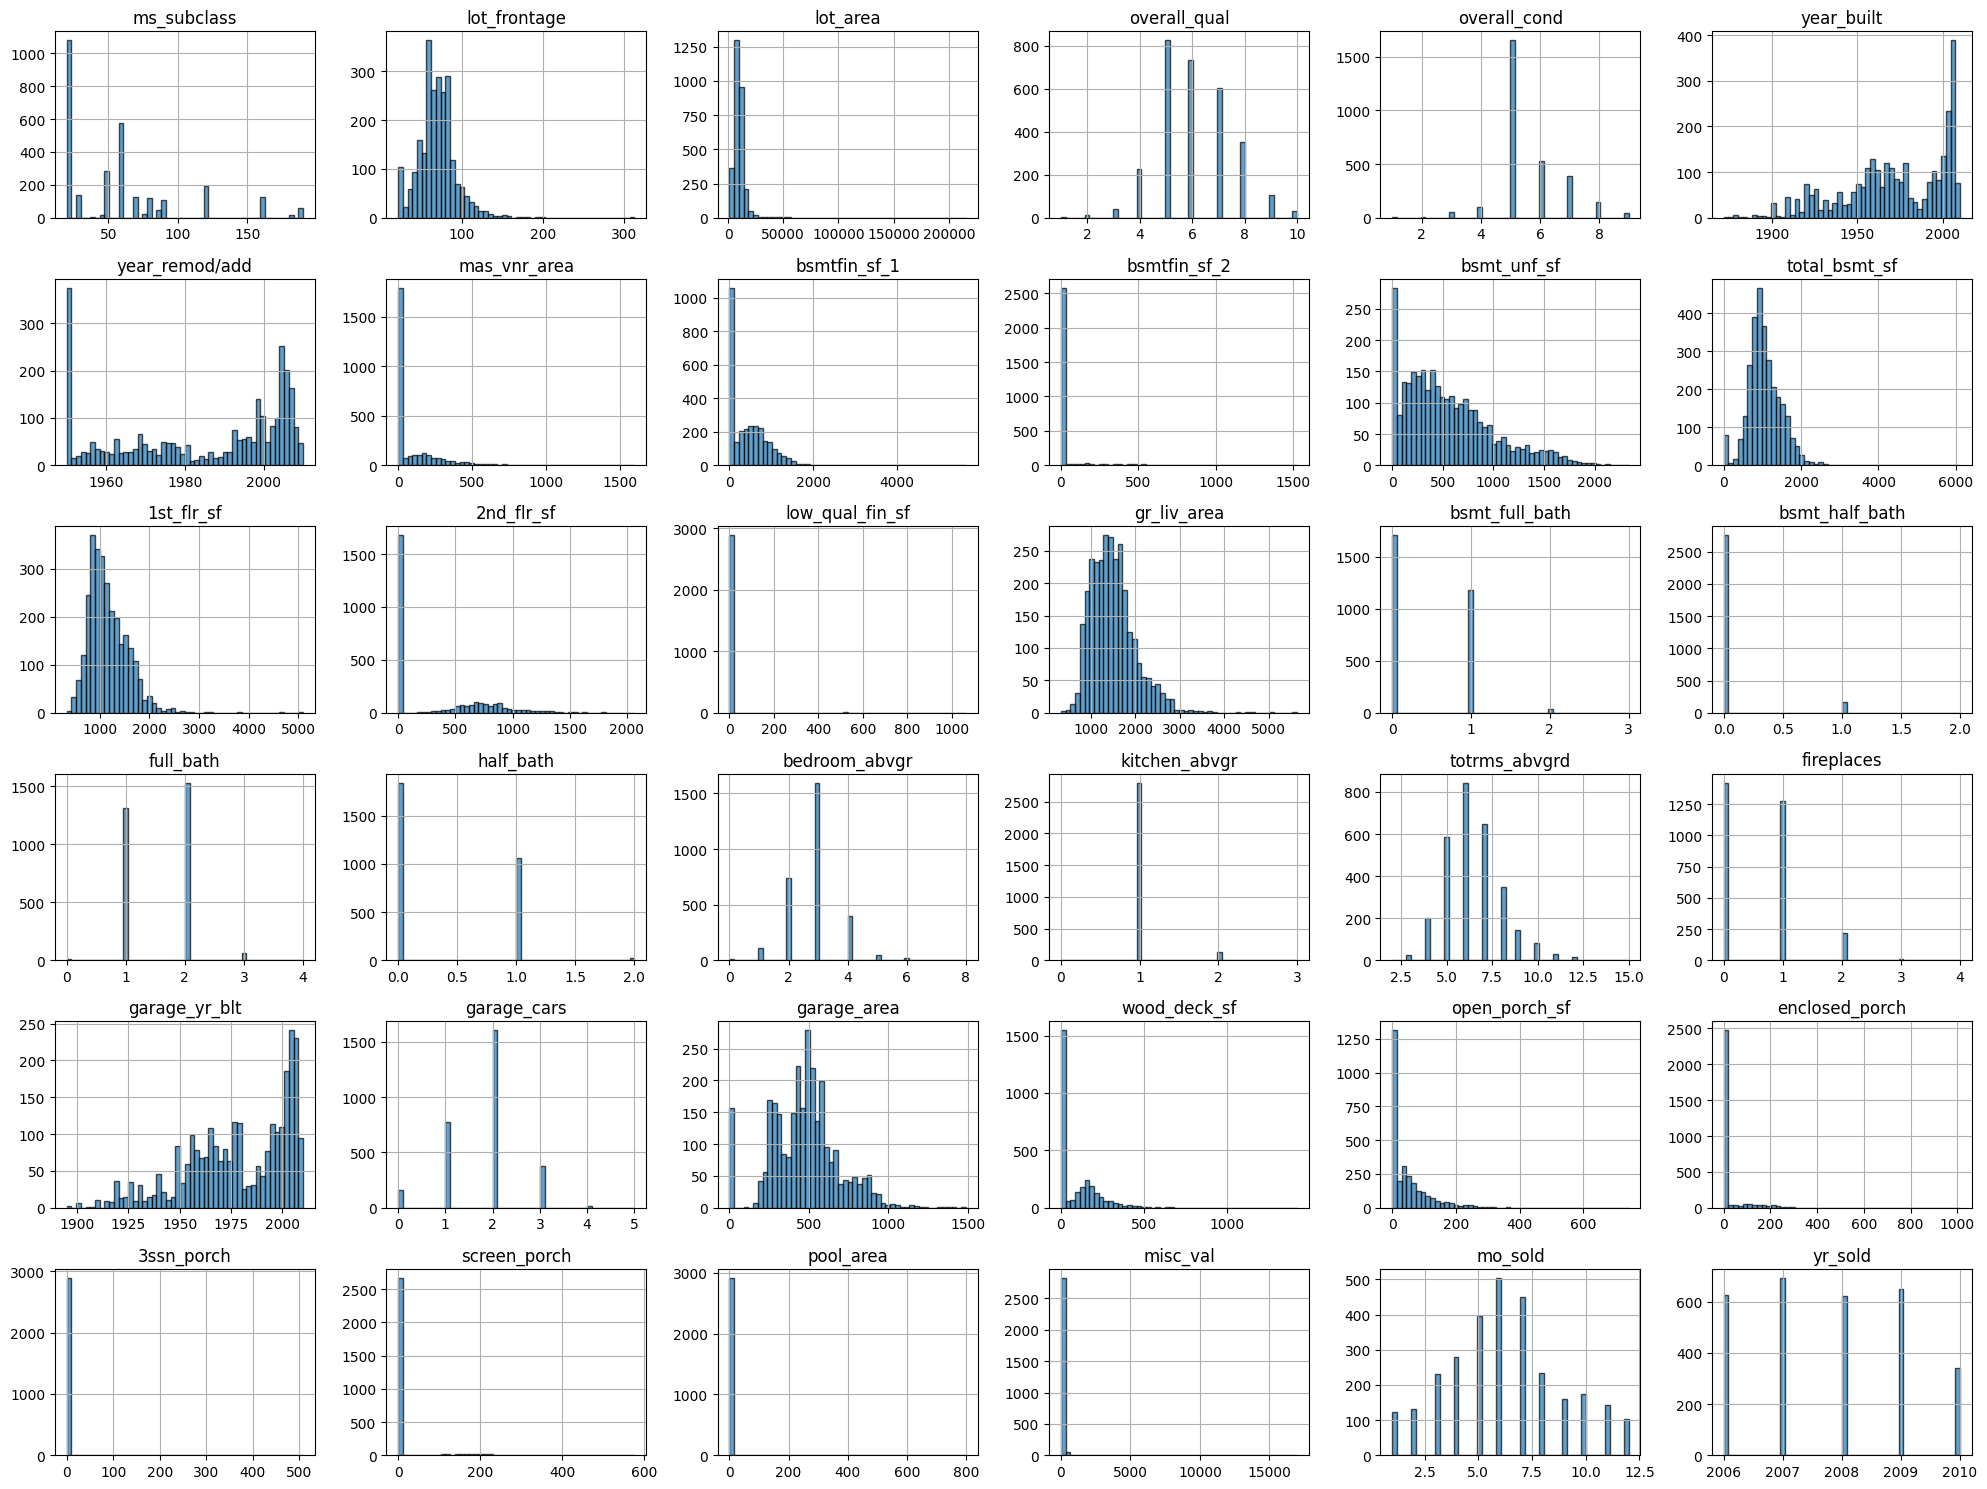

In [41]:
import matplotlib.pyplot as plt

X_numeric_features = X.select_dtypes(include=['int64', 'float64'])

X_numeric_features.hist(bins=50, figsize=(20, 15), edgecolor='black', alpha=0.7)

plt.tight_layout()
plt.show()

In [42]:
df['overall_qual'].value_counts()

overall_qual
5     825
6     732
7     602
8     350
4     226
9     107
3      40
10     31
2      13
1       4
Name: count, dtype: int64

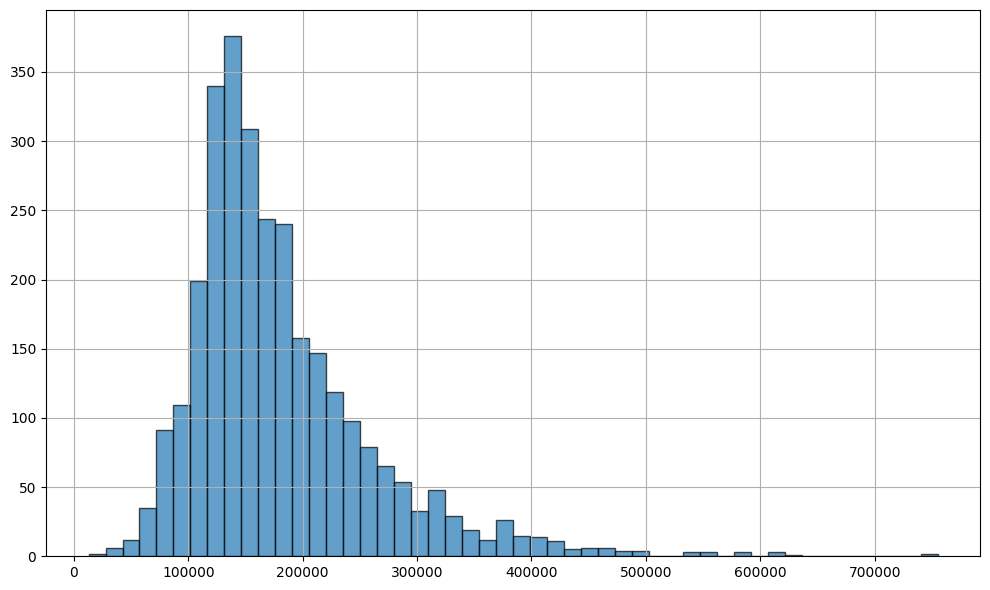

In [43]:
raw_target = df['saleprice']
raw_target.hist(bins=50, figsize=(10, 6), edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()

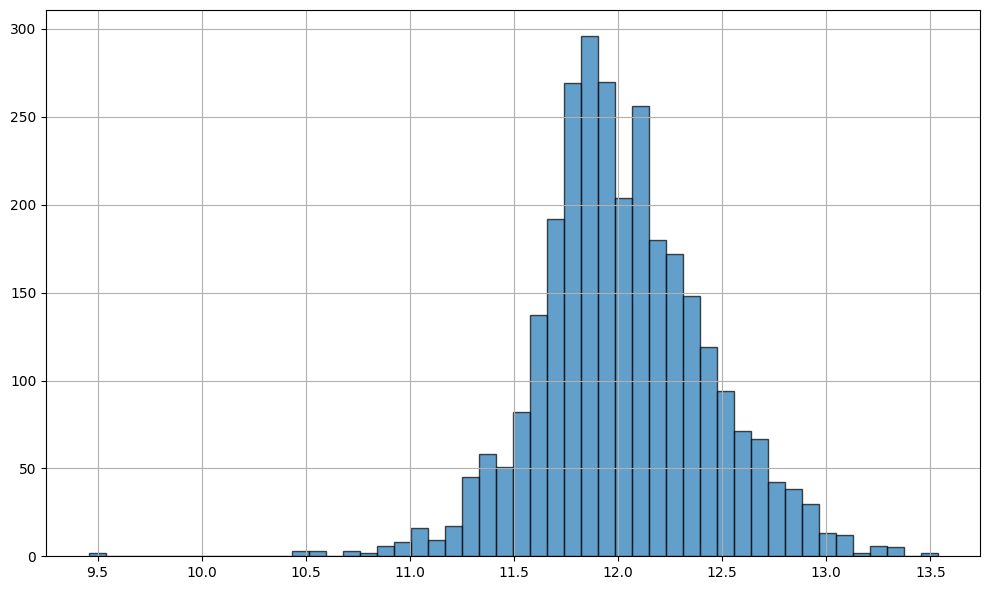

In [45]:
y=np.log1p(df['saleprice'])

y.hist(bins=50, figsize=(10, 6), edgecolor='black', alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in splitter.split(df, df['overall_qual']):
    X_train = X.iloc[train_index]
    X_val = X.iloc[val_index]
    y_train = y.iloc[train_index]
    y_val = y.iloc[val_index]


In [47]:
import pandas as pd
train_proportions = X_train['overall_qual'].value_counts(normalize=True).sort_index()
val_proportions = X_val['overall_qual'].value_counts(normalize=True).sort_index()

split_audit_df = pd.DataFrame({
    'Train Set Proportions (%)': train_proportions * 100,
    'Validation Set Proportions (%)': val_proportions * 100
})
print("--- Stratified Split Integrity Check ---")
print(split_audit_df.round(2))


--- Stratified Split Integrity Check ---
              Train Set Proportions (%)  Validation Set Proportions (%)
overall_qual                                                           
1                                  0.13                            0.17
2                                  0.43                            0.51
3                                  1.37                            1.37
4                                  7.72                            7.68
5                                 28.16                           28.16
6                                 25.00                           24.91
7                                 20.52                           20.65
8                                 11.95                           11.95
9                                  3.67                            3.58
10                                 1.07                            1.02
